# Default Classification Scheme Implementation

In [1]:
# Load luma-stack package
!python -m pip install .. --quiet

# Load libraries
import ee
import os
import geemap
import pandas as pd
import numpy as np
import importlib
import default_scheme
import rasterio
from rasterio.mask import mask
from rasterio.transform import from_bounds
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Load the default_scheme functions   
importlib.reload(default_scheme)

from default_scheme import (
    read_mosaic_rast,
    read_classification_scheme,
    build_mapping,
    aggregate_probability,
    predict_class
)

In [2]:
# Earth Engine initialization
ee.Authenticate()
ee.Initialize()

## Step 1: Define Inputs & Parameters

In [3]:
# Define input file path
aoi_path = "../data/modular_mapping_approach/musi-banyuasin_test/aoi_muba.shp"
multi_prob_map_path = "../data/modular_mapping_approach/musi-banyuasin_test/sumatra_multiprobability_stack_KLHK_30m-0000028672-0000028672.tif"
predictors_map_path = "../data/modular_mapping_approach/musi-banyuasin_test/predictors_map.tif"
modified_scheme_path = "../data/modular_mapping_approach/musi-banyuasin_test/modified_scheme.xlsx"
ruleset_path = "../data/modular_mapping_approach/musi-banyuasin_test/predictors_ruleset.xlsx"
year = 2020
output_path = "../data/modular_mapping_approach/musi-banyuasin_test/result/"
probability_threshold = 0.6


## Step 2: Load & Clip Map Input with AOI

In [4]:
# Load AOI
aoi_ee = geemap.shp_to_ee(aoi_path)
aoi_gdf = gpd.read_file(aoi_path) # for clipping purpose locally

# Load and clip multi-probability map  
raster_multi_prob, out_transform_prob, raster_meta_multi_prob, band_names_prob = read_mosaic_rast(multi_prob_map_path, aoi_gdf)

print('Available multi-probability map bands:')
for name in band_names_prob:
    print(f' - {name}')
    
# Load and clip predictors map
raster_multi_pred, out_transform_pred, raster_meta_pred, band_names_pred = read_mosaic_rast(predictors_map_path, aoi_gdf)

print('Available predictors map bands:')
for name in band_names_pred:
    print(f' - {name}')

Available multi-probability map bands:
 - Hutan_lahan_kering_primer
 - Hutan_lahan_kering_sekunder
 - Hutan_rawa_primer
 - Hutan_rawa_sekunder_bekas_tebangan
 - Hutan_mangrove_primer
 - Hutan_mangrove_sekunder_bekas_tebangan
 - Hutan_tanaman
 - Perkebunan_Kebun
 - Semak_belukar
 - Semak_belukar_rawa
 - Rumput
 - Pertanian_lahan_kering
 - Pertanian_Lahan_Kering_campur_semak
 - Sawah
 - Tambak
 - Permukiman_lahan_terbangun
 - Transmigrasi
 - Tanah_terbuka
 - Pertambangan
 - Tubuh_air
 - Rawa
 - Bandara_Pelabuhan
Available predictors map bands:
 - DEM_F10
 - distToRiver
 - distToSettle19


## Step 3: Define Classification Scheme & Required Probability Band

In [5]:
# Read scheme 
modified_scheme = pd.read_excel(modified_scheme_path)

# Define selected scheme
scheme = read_classification_scheme(modified_scheme)

# Build aggregation mapping
mapping = build_mapping(scheme)

# Aggregate probability cube
aggregated_cube, output_info = aggregate_probability(
    raster_multi_prob,
    mapping
)

output_info


,Output_ID,Output_Name,Output_Level,Color,Member_IDs,Member_Bands
0,1,Hutan lahan kering primer,3,#005500,[1],[0]
1,2,Hutan lahan kering sekunder/bekas tebangan,3,#009933,[2],[1]
2,3,Hutan rawa primer,3,#663300,[3],[2]
3,4,Hutan rawa sekunder/bekas tebangan,3,#996600,[4],[3]
4,5,Hutan mangrove primer,3,#80ffbf,[5],[4]
5,6,Hutan mangrove sekunder/bekas tebangan,3,#ffcc99,[6],[5]
6,7,Hutan tanaman,3,#00e5ff,[7],[6]
7,8,Perkebunan/Kebun,3,#7f14b8,[8],[7]
8,9,Semak belukar,3,#ffcc99,[9],[8]
9,10,Semak belukar rawa,3,#ccffe7,[10],[9]


## Step 4: Apply Argmax to Produce Final Classification

In [6]:
# Apply classification
classified_map, classified_meta, max_prob_map, argmax_indices, selected_class_ids = predict_class(
    aggregated_cube,
    output_info,
    raster_meta_multi_prob
)

Argmax classification completed.
Output shape: (1297, 2302)


## Step 5: Final Classification Visualisation

Final class distribution:
    Output_ID                                        Output_Name  Pixel_Count  \
0           0                                                           39389   
1           1                          Hutan lahan kering primer        10245   
2           2         Hutan lahan kering sekunder/bekas tebangan       396756   
3           3                                  Hutan rawa primer       151279   
4           4                 Hutan rawa sekunder/bekas tebangan        73913   
5           5                              Hutan mangrove primer       109069   
6           6             Hutan mangrove sekunder/bekas tebangan        38240   
7           7                                      Hutan tanaman        45324   
8           8                                   Perkebunan/Kebun       111469   
9           9                                      Semak belukar       410367   
10         10                                 Semak belukar rawa       279024   
11

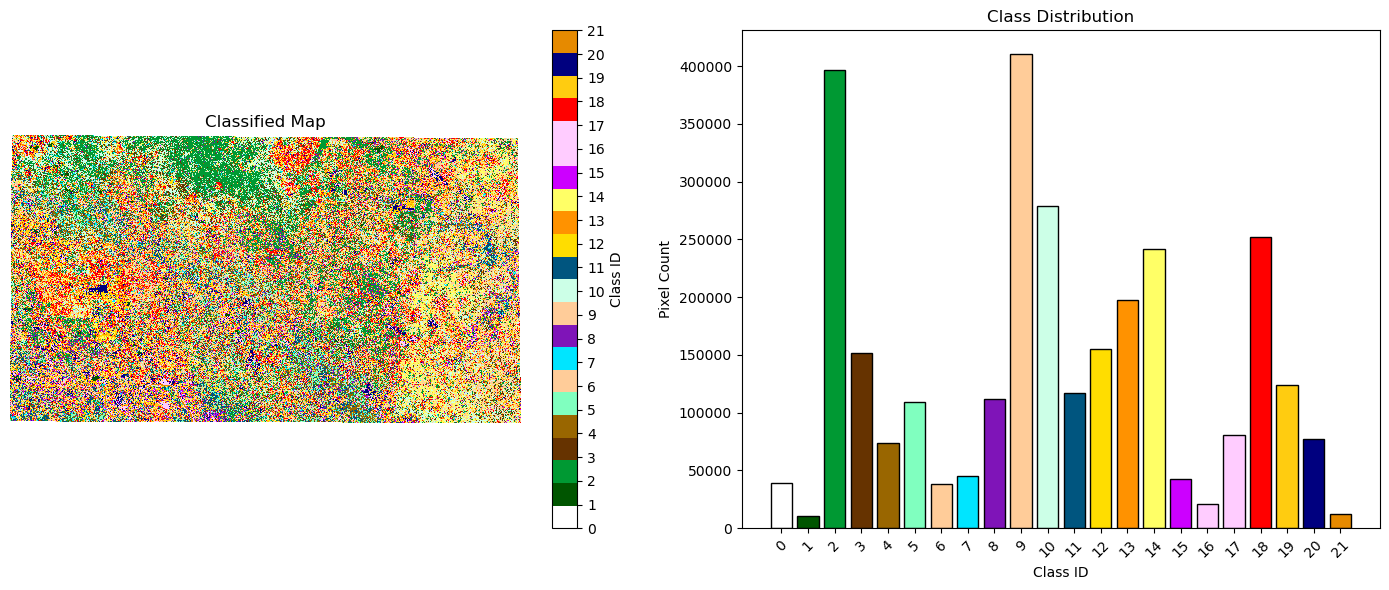

In [7]:
# Build pixel summary
unique_ids, counts = np.unique(classified_map, return_counts=True)
unique_ids = unique_ids.astype(int)

pixel_summary = pd.DataFrame({
    'Output_ID': unique_ids,
    'Pixel_Count': counts
})

pixel_summary = pixel_summary.merge(
    output_info[['Output_ID', 'Output_Name', 'Color']],
    on='Output_ID',
    how='left'
)

# Fill missing values
DEFAULT_COLOR = '#ffffff'  
DEFAULT_NAME = ''  
pixel_summary['Color'] = pixel_summary['Color'].fillna(DEFAULT_COLOR)
pixel_summary['Output_Name'] = pixel_summary['Output_Name'].fillna(DEFAULT_NAME)

# Add percentage column
total_pixels = pixel_summary['Pixel_Count'].sum()
pixel_summary['Percentage'] = 100 * pixel_summary['Pixel_Count'] / total_pixels
pixel_summary = pixel_summary.sort_values('Output_ID').reset_index(drop=True)

print('Final class distribution:')
print(pixel_summary[['Output_ID', 'Output_Name', 'Pixel_Count', 'Percentage']])

cmap = ListedColormap(pixel_summary['Color'].tolist())
indices = np.searchsorted(pixel_summary['Output_ID'].values, classified_map)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# PLot Classified map
im = ax[0].imshow(indices, cmap=cmap, interpolation='nearest')
ax[0].set_title('Classified Map')
ax[0].axis('off')

# Colorbar 
cbar = fig.colorbar(im, ax=ax[0], label='Class ID', ticks=range(len(pixel_summary)))
cbar.ax.set_yticklabels(pixel_summary['Output_ID'].astype(str))

# Pixel count bar chart
colors = pixel_summary['Color'].tolist()
ax[1].bar(pixel_summary['Output_ID'].astype(str), pixel_summary['Pixel_Count'],
          color=colors, edgecolor='black')
ax[1].set_title('Class Distribution')
ax[1].set_xlabel('Class ID')
ax[1].set_ylabel('Pixel Count')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_path = '../data/modular_mapping_approach/musi-banyuasin_test/muba_classified_map.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Export Final Map

In [9]:
# Define output directory and file name
os.makedirs(output_path, exist_ok=True)
output_file = os.path.join(output_path, "muba_classified_map.tif")

# Get geometry properties from AOI as reference 
minx, miny, maxx, maxy = aoi_gdf.total_bounds  
crs = aoi_gdf.crs 
height, width = classified_map.shape
transform = from_bounds(minx, miny, maxx, maxy, width, height)

profile = {
    'driver': 'GTiff',
    'height': height,
    'width': width,
    'count': 1,
    'dtype': rasterio.int32,
    'crs': crs,
    'transform': transform,
    'compress': 'lzw',    
    'nodata': 0           
}

# Export
with rasterio.open(output_file, 'w', **profile) as dst:
    dst.write(classified_map.astype(np.int32), 1)